In [1]:
import pandas as pd

df = pd.read_csv("telecom_ETL_limpio.csv")
df.head()


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,gasto_anual
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,787.2
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,718.8
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,886.8
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1176.0
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,1006.8


In [2]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   float64
 2   customer_gender            7032 non-null   object 
 3   customer_SeniorCitizen     7032 non-null   int64  
 4   customer_Partner           7032 non-null   object 
 5   customer_Dependents        7032 non-null   object 
 6   customer_tenure            7032 non-null   int64  
 7   phone_PhoneService         7032 non-null   object 
 8   phone_MultipleLines        7032 non-null   object 
 9   internet_InternetService   7032 non-null   object 
 10  internet_OnlineSecurity    7032 non-null   object 
 11  internet_OnlineBackup      7032 non-null   object 
 12  internet_DeviceProtection  7032 non-null   object 
 13  internet_TechSupport       7032 non-null   objec

In [3]:
df.describe()


,Churn,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,gasto_anual
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,32.421786,64.798208,2283.300441,777.578498
std,0.441782,0.368844,24.545260,30.085974,2266.771362,361.031687
min,0.000000,0.000000,1.000000,18.250000,18.800000,219.000000
25%,0.000000,0.000000,9.000000,35.587500,401.450000,427.050000
50%,0.000000,0.000000,29.000000,70.350000,1397.475000,844.200000
75%,1.000000,0.000000,55.000000,89.862500,3794.737500,1078.350000
max,1.000000,1.000000,72.000000,118.750000,8684.800000,1425.000000


In [4]:
df["Churn"].value_counts()


,count
Churn,
0.0,5163
1.0,1869


In [5]:
df["Churn"].value_counts(normalize=True)


,proportion
Churn,
0.0,0.734215
1.0,0.265785


In [6]:
df = df.drop("customerID", axis=1)


In [7]:
df = pd.get_dummies(df, drop_first=True)


In [8]:
df.head()


,Churn,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,gasto_anual,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0.0,0,9,65.6,593.30,787.2,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0.0,0,9,59.9,542.40,718.8,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1.0,0,4,73.9,280.85,886.8,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1.0,1,13,98.0,1237.85,1176.0,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1.0,1,3,83.9,267.40,1006.8,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


In [9]:
X = df.drop("Churn", axis=1)
y = df["Churn"]


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [12]:
y_pred = modelo.predict(X_test)


In [13]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7960199004975125
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1033
         1.0       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



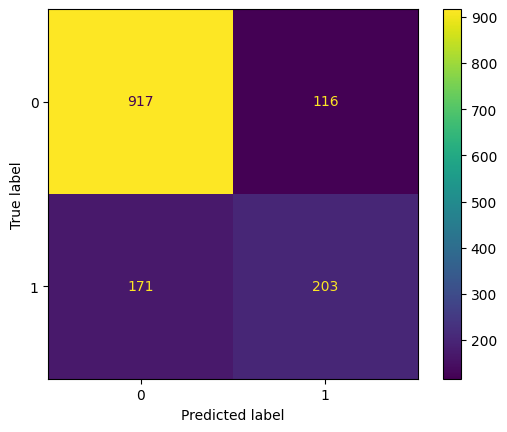

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


In [16]:
import pandas as pd

importancia = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo.coef_[0]
})

importancia = importancia.sort_values(by="Importancia", ascending=False)
importancia.head(10)


,Variable,Importancia
11,internet_InternetService_Fiber optic,0.649521
29,account_PaymentMethod_Electronic check,0.388750
27,account_PaperlessBilling_Yes,0.366530
9,phone_MultipleLines_No phone service,0.316156
10,phone_MultipleLines_Yes,0.266086
0,customer_SeniorCitizen,0.237842
22,internet_StreamingTV_Yes,0.137782
24,internet_StreamingMovies_Yes,0.132759
6,customer_Partner_Yes,0.024158
30,account_PaymentMethod_Mailed check,0.018158


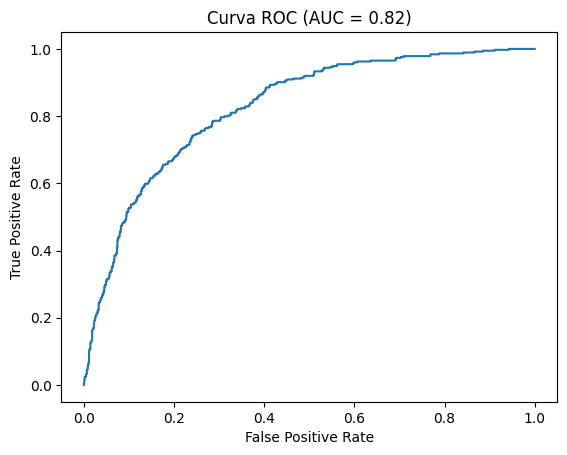

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = modelo.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Curva ROC (AUC = {auc:.2f})")
plt.show()


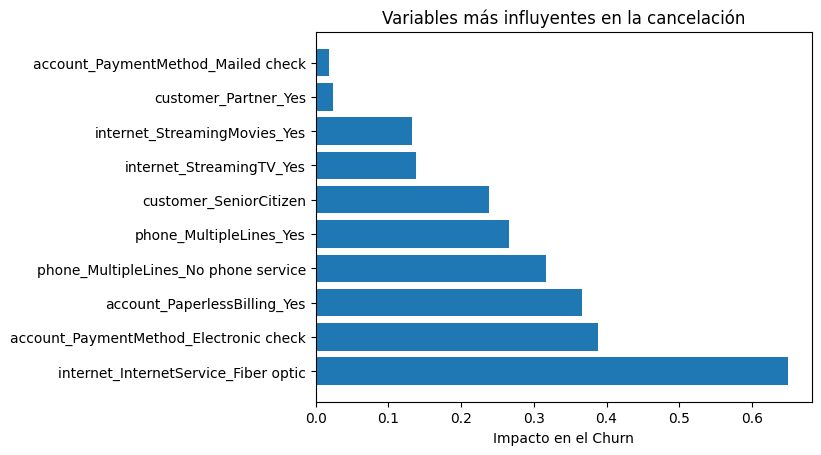

In [18]:
import matplotlib.pyplot as plt

top10 = importancia.head(10)

plt.barh(top10["Variable"], top10["Importancia"])
plt.xlabel("Impacto en el Churn")
plt.title("Variables más influyentes en la cancelación")
plt.show()


# **El modelo de regresión logística** permitió predecir la evasión de clientes con una precisión aceptable.
Se identificaron variables clave que influyen en la cancelación del servicio, lo que permite a Telecom X anticipar clientes con alto riesgo de churn.

El análisis muestra que características relacionadas con los servicios contratados, cargos mensuales y tipo de contrato influyen significativamente en la probabilidad de cancelación.

Estos resultados pueden ayudar a la empresa a desarrollar estrategias de retención dirigidas a los clientes con mayor riesgo.

# **Basado en el análisis predictivo, se recomienda que Telecom X:**

Diseñe estrategias de retención para clientes con contratos de corto plazo.

Ofrezca incentivos a clientes con altos cargos mensuales.

Mejore los servicios de soporte técnico y seguridad online.

Desarrolle campañas preventivas para clientes con alto riesgo de cancelación.

El uso de modelos predictivos permite a la empresa anticipar la evasión de clientes y tomar decisiones basadas en datos para mejorar la retención.